In [1]:
import numpy as np
import pandas as pd
import gym
from gym import spaces

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from stable_baselines3 import PPO, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.noise import NormalActionNoise

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
df1 = pd.read_csv('Data/UNSW_NB15_training-set.csv')
df2 = pd.read_csv('Data/UNSW_NB15_testing-set.csv')

df = pd.concat([df1, df2], ignore_index=True)

In [3]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
df.shape

(257673, 45)

In [5]:
df.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [6]:
df.tail()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
257668,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
257669,175338,0.505762,tcp,-,FIN,10,8,620,354,33.612649,...,1,2,0,0,0,1,1,0,Shellcode,1
257670,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
257671,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1
257672,175341,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,16,30,0,0,0,30,30,0,Generic,1


In [7]:
# Drop unused columns
df.drop(['id', 'attack_cat'], axis=1, inplace=True)

In [8]:
# Separate features and label
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [9]:
# One-hot encode categorical features
X = pd.get_dummies(X, columns=['proto', 'service', 'state'])

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(206138, 196) (51535, 196)


In [12]:
class IDSMDPEnv(gym.Env):
    def __init__(self, X, y):
        super(IDSMDPEnv, self).__init__()
        
        self.X = X
        self.y = y
        self.index = 0
        
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(X.shape[1],),
            dtype=np.float32
        )
        
        self.action_space = spaces.Discrete(2)

    def reset(self):
        self.index = 0
        return self.X[self.index]

    def step(self, action):
        true_label = self.y.iloc[self.index]

        # Reward function
        if action == true_label:
            reward = 1.0
        elif action == 1 and true_label == 0:
            reward = -1.0  # False Positive
        else:
            reward = -2.0  # False Negative

        self.index += 1
        done = self.index >= len(self.X) - 1

        next_state = self.X[self.index] if not done else np.zeros(self.X.shape[1])

        return next_state, reward, done, {}

In [13]:
env = DummyVecEnv([lambda: IDSMDPEnv(X_train, y_train)])

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [14]:
class IDSMDPEnvDDPG(IDSMDPEnv):
    def __init__(self, X, y):
        super().__init__(X, y)
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,))
        
    def step(self, action):
        action = int(action[0] > 0.5)
        return super().step(action)

In [15]:
env_ddpg = DummyVecEnv([lambda: IDSMDPEnvDDPG(X_train, y_train)])

In [19]:
policy_kwargs = dict(
    net_arch=[512, 256, 128],
    activation_fn=nn.ReLU
)

In [20]:
ppo_model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    batch_size=256,
    n_steps=2048
)

ppo_model.learn(total_timesteps=200_000)

ppo_model.save("Saved Model")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1640 |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 4096 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1170        |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.010195735 |
|    clip_fraction        | 0.19        |
|    clip_range           | 0.15        |
|    entropy_loss         | -0.687      |
|    explained_variance   | -0.0101     |
|    learning_rate        | 0.00025     |
|    loss                 | 8.62        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0201     |
|    value_loss           | 25.1        |
-----------------------------------------
-----------------

In [21]:
def evaluate(model, X, y, is_ddpg=False):
    env = IDSMDPEnvDDPG(X, y) if is_ddpg else IDSMDPEnv(X, y)
    obs = env.reset()
    
    correct = 0
    for i in range(len(X)-1):
        action, _ = model.predict(obs, deterministic=True)
        if is_ddpg:
            action = int(action[0] > 0.5)
        correct += int(action == y.iloc[i])
        obs, _, done, _ = env.step(action)
        if done:
            break
    
    return correct / len(X)

In [22]:
ppo_acc = evaluate(ppo_model, X_test, y_test)
print("PPO Accuracy :", ppo_acc)

PPO Accuracy : 0.899078296303483


In [23]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

In [24]:

def get_predictions(model, X, y):
    env = IDSMDPEnv(X, y)
    obs = env.reset()
    y_true, y_pred, y_prob = [], [], []
    for i in range(len(X)-1):
        action, prob = model.predict(obs, deterministic=True)
        y_true.append(y.iloc[i])
        y_pred.append(action)
        # PPO does not output probability → approximate
        y_prob.append(float(action))
        obs, _, done, _ = env.step(action)
        if done:
            break
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [25]:
y_true, y_pred, y_prob = get_predictions(ppo_model, X_test, y_test)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.8991
Precision: 0.8682
Recall   : 0.9928
F1-score : 0.9263
ROC-AUC  : 0.8630


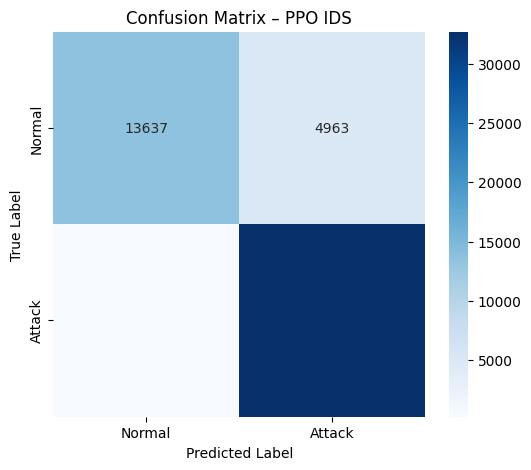

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – PPO IDS")
plt.show()

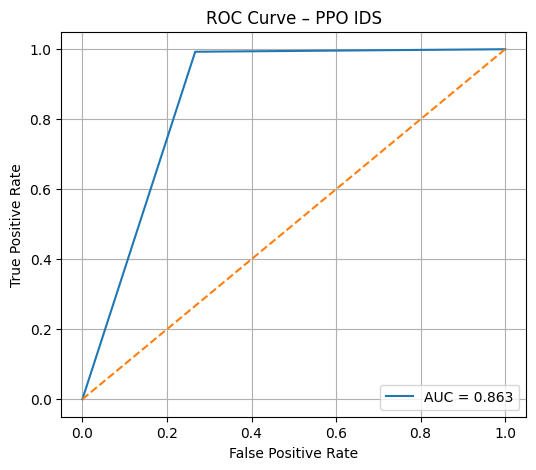

In [27]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – PPO IDS')
plt.legend()
plt.grid()
plt.show()

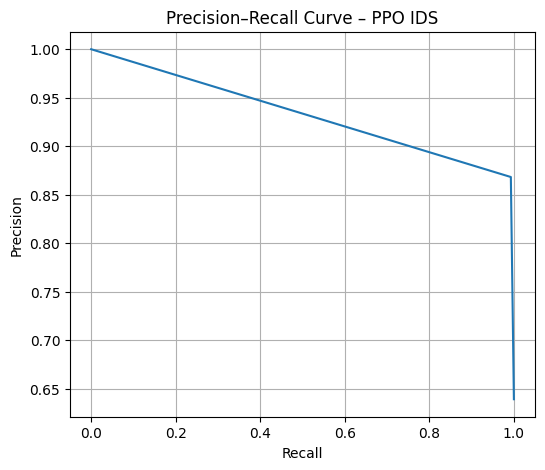

In [43]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve – PPO IDS')
plt.grid()
plt.show()

In [29]:
episode_rewards = []

class IDSMDPEnvLog(IDSMDPEnv):
    def __init__(self, X, y):
        super().__init__(X, y)
        self.episode_reward = 0

    def reset(self):
        if self.episode_reward != 0:
            episode_rewards.append(self.episode_reward)
        self.episode_reward = 0
        return super().reset()

    def step(self, action):
        obs, reward, done, info = super().step(action)
        self.episode_reward += reward
        return obs, reward, done, info

In [30]:
env = DummyVecEnv([lambda: IDSMDPEnvLog(X_train, y_train)])
ppo_model = PPO("MlpPolicy", env, verbose=1)
ppo_model.learn(total_timesteps=300_000)

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 3817 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 2015       |
|    iterations           | 2          |
|    time_elapsed         | 2          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01662441 |
|    clip_fraction        | 0.278      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.681     |
|    explained_variance   | -0.0108    |
|    learning_rate        | 0.0003     |
|    loss                 | 8.61       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0379    |
|    value_loss           | 26.4       |
----------------------------------------
-----------------------------------

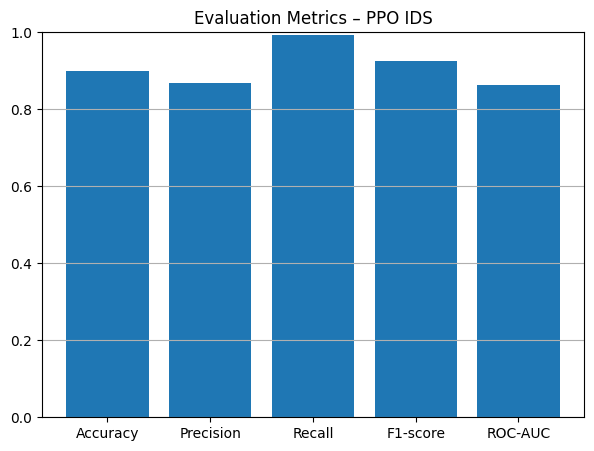

In [32]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
values = [acc, prec, rec, f1, auc]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.title("Evaluation Metrics – PPO IDS")
plt.grid(axis='y')
plt.show()

In [33]:
from stable_baselines3 import PPO

ppo_model = PPO.load("Saved Model")
print("PPO model loaded successfully")


PPO model loaded successfully


In [34]:
def predict_with_ppo(model, X, y=None):
    env = IDSMDPEnv(X, y if y is not None else pd.Series(np.zeros(len(X))))
    obs = env.reset()

    predictions = []

    for i in range(len(X)-1):
        action, _ = model.predict(obs, deterministic=True)
        predictions.append(action)
        obs, _, done, _ = env.step(action)
        if done:
            break

    return np.array(predictions)

In [35]:
y_pred_test = predict_with_ppo(ppo_model, X_test, y_test)

print("Sample Predictions:", y_pred_test[:20])

Sample Predictions: [1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1]


In [37]:
import torch
import numpy as np

def predict_single_row_with_prob(ppo_model, X_test, row_index):
    # Extract single row
    obs = X_test[row_index].reshape(1, -1)

    # Convert to torch tensor
    obs_tensor = torch.tensor(obs).float()

    # Get action distribution from PPO policy
    with torch.no_grad():
        distribution = ppo_model.policy.get_distribution(obs_tensor)
        probs = distribution.distribution.probs.cpu().numpy()[0]

    # Prediction
    predicted_class = np.argmax(probs)
    confidence = probs[predicted_class] * 100

    label_map = {0: "Normal", 1: "Attack"}

    return {
        "Row Index": row_index,
        "Predicted Class": predicted_class,
        "Predicted Label": label_map[predicted_class],
        "Normal Probability (%)": round(probs[0] * 100, 2),
        "Attack Probability (%)": round(probs[1] * 100, 2),
        "Confidence (%)": round(confidence, 2)
    }

In [42]:
row_number = 1000

result = predict_single_row_with_prob(ppo_model, X_test, row_number)

for k, v in result.items():
    print(f"{k}: {v}")

Row Index: 1000
Predicted Class: 0
Predicted Label: Normal
Normal Probability (%): 99.98
Attack Probability (%): 0.02
Confidence (%): 99.98


In [44]:
import torch

torch.save(scaler, "scaler.pt")
torch.save(list(X.columns), "features.pt")